# Preprocessing

## Importation

In [2]:
import nltk                                # Python library for NLP
import matplotlib.pyplot as plt            # library for visualization
import random    
import pandas as pd 
import seaborn as sns
import math                         # pseudo-random number generator

## Importation du MASTER DATASET BRUT
Il s'agit d'une base de données brute collectée à partir de différentes sources : Twitter, StockTwits, Reddit, News API, Yahoo Finance, Google News et divers flux RSS financiers.

In [3]:
df= pd.read_csv(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\MASTER_DATASET_BRUT_MAX.csv")

In [4]:
df

,Date,Source,Ticker,Titre
0,2026-07-12,Yahoo,MSFT,"Could SpaceX's Starmind Make Amazon's, Microso..."
1,2026-07-12,Yahoo,GOOGL,Big Tech’s Massive AI Spending Is Just Startin...
2,2026-07-12,Yahoo,META,Daniel Newman Says Meta Isn't Replacing Nvidia...
3,2026-07-12,Yahoo,META,Broadcom vs. Marvell: A Valuation Showdown for...
4,2026-07-12,Yahoo,META,The U.S. Economy Is Addicted to AI Spending. W...
...,...,...,...,...
3901767,2018-07-26,Benzinga,GOOGL,Google Cloud Next Event Concludes Today
3901768,2018-07-26,Benzinga,GOOGL,"Stocks Which Set New 52-Week High Yesterday, J..."
3901769,2018-07-25,Benzinga,GOOGL,"Social Media, FANG Stocks Taking A Big Hit In ..."
3901770,2018-07-25,Benzinga,GOOGL,Social Stocks Following Facebook Lower After H...


In [5]:

df['Date'] = df['Date'].astype(str).str[:10]


df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


df = df.sort_values(by='Date', ascending=False)


df = df.reset_index(drop=True)

# 6. Vérification visuelle
print(f"Dimensions du dataset trié : {df.shape}")
display(df.head())

Dimensions du dataset trié : (3901772, 4)


,Date,Source,Ticker,Titre
0,2026-07-12,Yahoo,MSFT,"Could SpaceX's Starmind Make Amazon's, Microso..."
1,2026-07-12,Yahoo,TSLA,Elon Musk Says Tesla Robot Will Be ‘Biggest Pr...
2,2026-07-12,Yahoo,AMZN,Synchrony (SYF) Announces Executive Leadership...
3,2026-07-12,CNBC,AMZN,Top Wall Street analysts are confident about t...
4,2026-07-12,Yahoo,AMZN,The U.S. Economy Is Addicted to AI Spending. W...


In [6]:
df

,Date,Source,Ticker,Titre
0,2026-07-12,Yahoo,MSFT,"Could SpaceX's Starmind Make Amazon's, Microso..."
1,2026-07-12,Yahoo,TSLA,Elon Musk Says Tesla Robot Will Be ‘Biggest Pr...
2,2026-07-12,Yahoo,AMZN,Synchrony (SYF) Announces Executive Leadership...
3,2026-07-12,CNBC,AMZN,Top Wall Street analysts are confident about t...
4,2026-07-12,Yahoo,AMZN,The U.S. Economy Is Addicted to AI Spending. W...
...,...,...,...,...
3901767,2018-07-26,Benzinga,GOOGL,Google Cloud Next Event Concludes Today
3901768,2018-07-26,Benzinga,GOOGL,"Stocks Which Set New 52-Week High Yesterday, J..."
3901769,2018-07-25,Benzinga,GOOGL,"Social Media, FANG Stocks Taking A Big Hit In ..."
3901770,2018-07-25,Benzinga,GOOGL,Social Stocks Following Facebook Lower After H...


In [7]:
df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')

display(df.head())

,Date,Source,Ticker,Titre
0,2026-07-12,Yahoo,MSFT,"Could SpaceX's Starmind Make Amazon's, Microso..."
1,2026-07-12,Yahoo,TSLA,Elon Musk Says Tesla Robot Will Be ‘Biggest Pr...
2,2026-07-12,Yahoo,AMZN,Synchrony (SYF) Announces Executive Leadership...
3,2026-07-12,CNBC,AMZN,Top Wall Street analysts are confident about t...
4,2026-07-12,Yahoo,AMZN,The U.S. Economy Is Addicted to AI Spending. W...


In [8]:
df.nunique()

Date         2738
Source         61
Ticker         10
Titre     3532546
dtype: int64

In [9]:
# Extraction des valeurs uniques
tickers_uniques = df['Ticker'].unique()

# Affichage du nombre total et de la liste
print(f"🏷️ Il y a {len(tickers_uniques)} Tickers uniques dans le dataset :")
print(tickers_uniques)

🏷️ Il y a 10 Tickers uniques dans le dataset :
['MSFT' 'TSLA' 'AMZN' 'JPM' 'GOOGL' 'META' 'AAPL' 'BRK.B' 'UNH' 'BRK-B']


In [10]:
# 1. Remplacement strict de "BRK.B" par "BRK-B"
df['Ticker'] = df['Ticker'].replace({'BRK.B': 'BRK-B'})

# 2. On relance l'affichage pour vérifier la correction
tickers_uniques = df['Ticker'].unique()
print("✅ Standardisation terminée !")
print(f"🏷️ Liste propre des {len(tickers_uniques)} Tickers uniques :")
print(tickers_uniques)

✅ Standardisation terminée !
🏷️ Liste propre des 9 Tickers uniques :
['MSFT' 'TSLA' 'AMZN' 'JPM' 'GOOGL' 'META' 'AAPL' 'BRK-B' 'UNH']


In [11]:
df.tail()

,Date,Source,Ticker,Titre
3901767,2018-07-26,Benzinga,GOOGL,Google Cloud Next Event Concludes Today
3901768,2018-07-26,Benzinga,GOOGL,"Stocks Which Set New 52-Week High Yesterday, J..."
3901769,2018-07-25,Benzinga,GOOGL,"Social Media, FANG Stocks Taking A Big Hit In ..."
3901770,2018-07-25,Benzinga,GOOGL,Social Stocks Following Facebook Lower After H...
3901771,2018-07-25,Benzinga,GOOGL,Pro: Why Alphabet Is A Better Pick Than Facebook


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

df = df[df['Date'] >= '2020-01-01']

df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')
df = df.reset_index(drop=True)

print(f" Données pré-2020 supprimées !")
print(f" Nouvelles dimensions du Master Dataset : {df.shape}")

C:\Users\semy4\AppData\Local\Temp\ipykernel_39388\114125859.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')


 Données pré-2020 supprimées !
 Nouvelles dimensions du Master Dataset : (3897662, 4)


In [13]:
df.head()

,Date,Source,Ticker,Titre
0,2026-07-12,Yahoo,MSFT,"Could SpaceX's Starmind Make Amazon's, Microso..."
1,2026-07-12,Yahoo,TSLA,Elon Musk Says Tesla Robot Will Be ‘Biggest Pr...
2,2026-07-12,Yahoo,AMZN,Synchrony (SYF) Announces Executive Leadership...
3,2026-07-12,CNBC,AMZN,Top Wall Street analysts are confident about t...
4,2026-07-12,Yahoo,AMZN,The U.S. Economy Is Addicted to AI Spending. W...


In [14]:
df.tail()

,Date,Source,Ticker,Titre
3897657,2020-01-01,StockTwits,TSLA,Tesla faces lawsuit claiming racism https://se...
3897658,2020-01-01,StockTwits,TSLA,@NyParker @dennismccain My opinion on $NIO (I ...
3897659,2020-01-01,StockTwits,TSLA,$TSLA haha just a collection of greats...&quot...
3897660,2020-01-01,StockTwits,TSLA,Tesla faces lawsuit claiming racism https://se...
3897661,2020-01-01,StockTwits,TSLA,"$TSLA should be the play of the day, either 50..."


## EDA

In [15]:
df.isnull().sum()

Date      0
Source    0
Ticker    0
Titre     0
dtype: int64

In [16]:
nombre_doublons = df.duplicated().sum()

print(f" Alerte : {nombre_doublons} lignes 100% identiques détectées !")
print(f" Dimensions avant purge : {df.shape}")

 Alerte : 96 lignes 100% identiques détectées !
 Dimensions avant purge : (3897662, 4)


In [17]:
df = df.drop_duplicates(ignore_index=True)

print(f"🧹 Purge terminée avec succès !")
print(f"🎯 Nouvelles dimensions du dataset : {df.shape}")

🧹 Purge terminée avec succès !
🎯 Nouvelles dimensions du dataset : (3897566, 4)


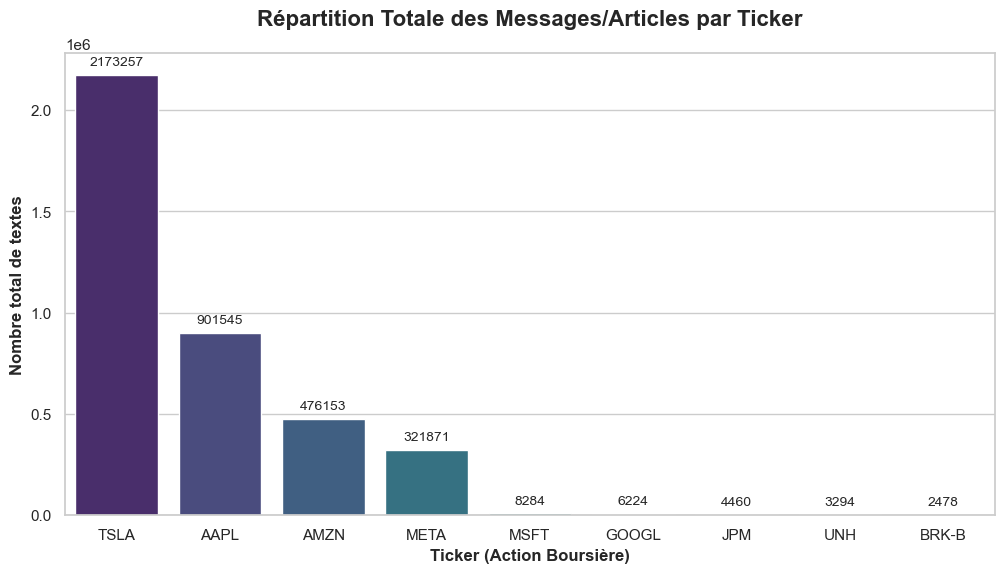

Tableau récapitulatif :


,Nombre de textes
Ticker,
TSLA,2173257
AAPL,901545
AMZN,476153
META,321871
MSFT,8284
GOOGL,6224
JPM,4460
UNH,3294
BRK-B,2478


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


repartition_ticker = df['Ticker'].value_counts()


plt.figure(figsize=(12, 6))


ax = sns.barplot(x=repartition_ticker.index, y=repartition_ticker.values, palette="viridis")


plt.title('Répartition Totale des Messages/Articles par Ticker', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ticker (Action Boursière)', fontsize=12, fontweight='bold')
plt.ylabel('Nombre total de textes', fontsize=12, fontweight='bold')


for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10)


plt.show()


print("Tableau récapitulatif :")
display(repartition_ticker.to_frame(name='Nombre de textes'))

In [19]:
chemin_final = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\MASTER_DATASET_BRUT_MAX_processed.csv"
df.to_csv(chemin_final, index=False, encoding='utf-8')

print(f"Fichier brut sauvegardé dans : {chemin_final}")

Fichier brut sauvegardé dans : C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\MASTER_DATASET_BRUT_MAX_processed.csv


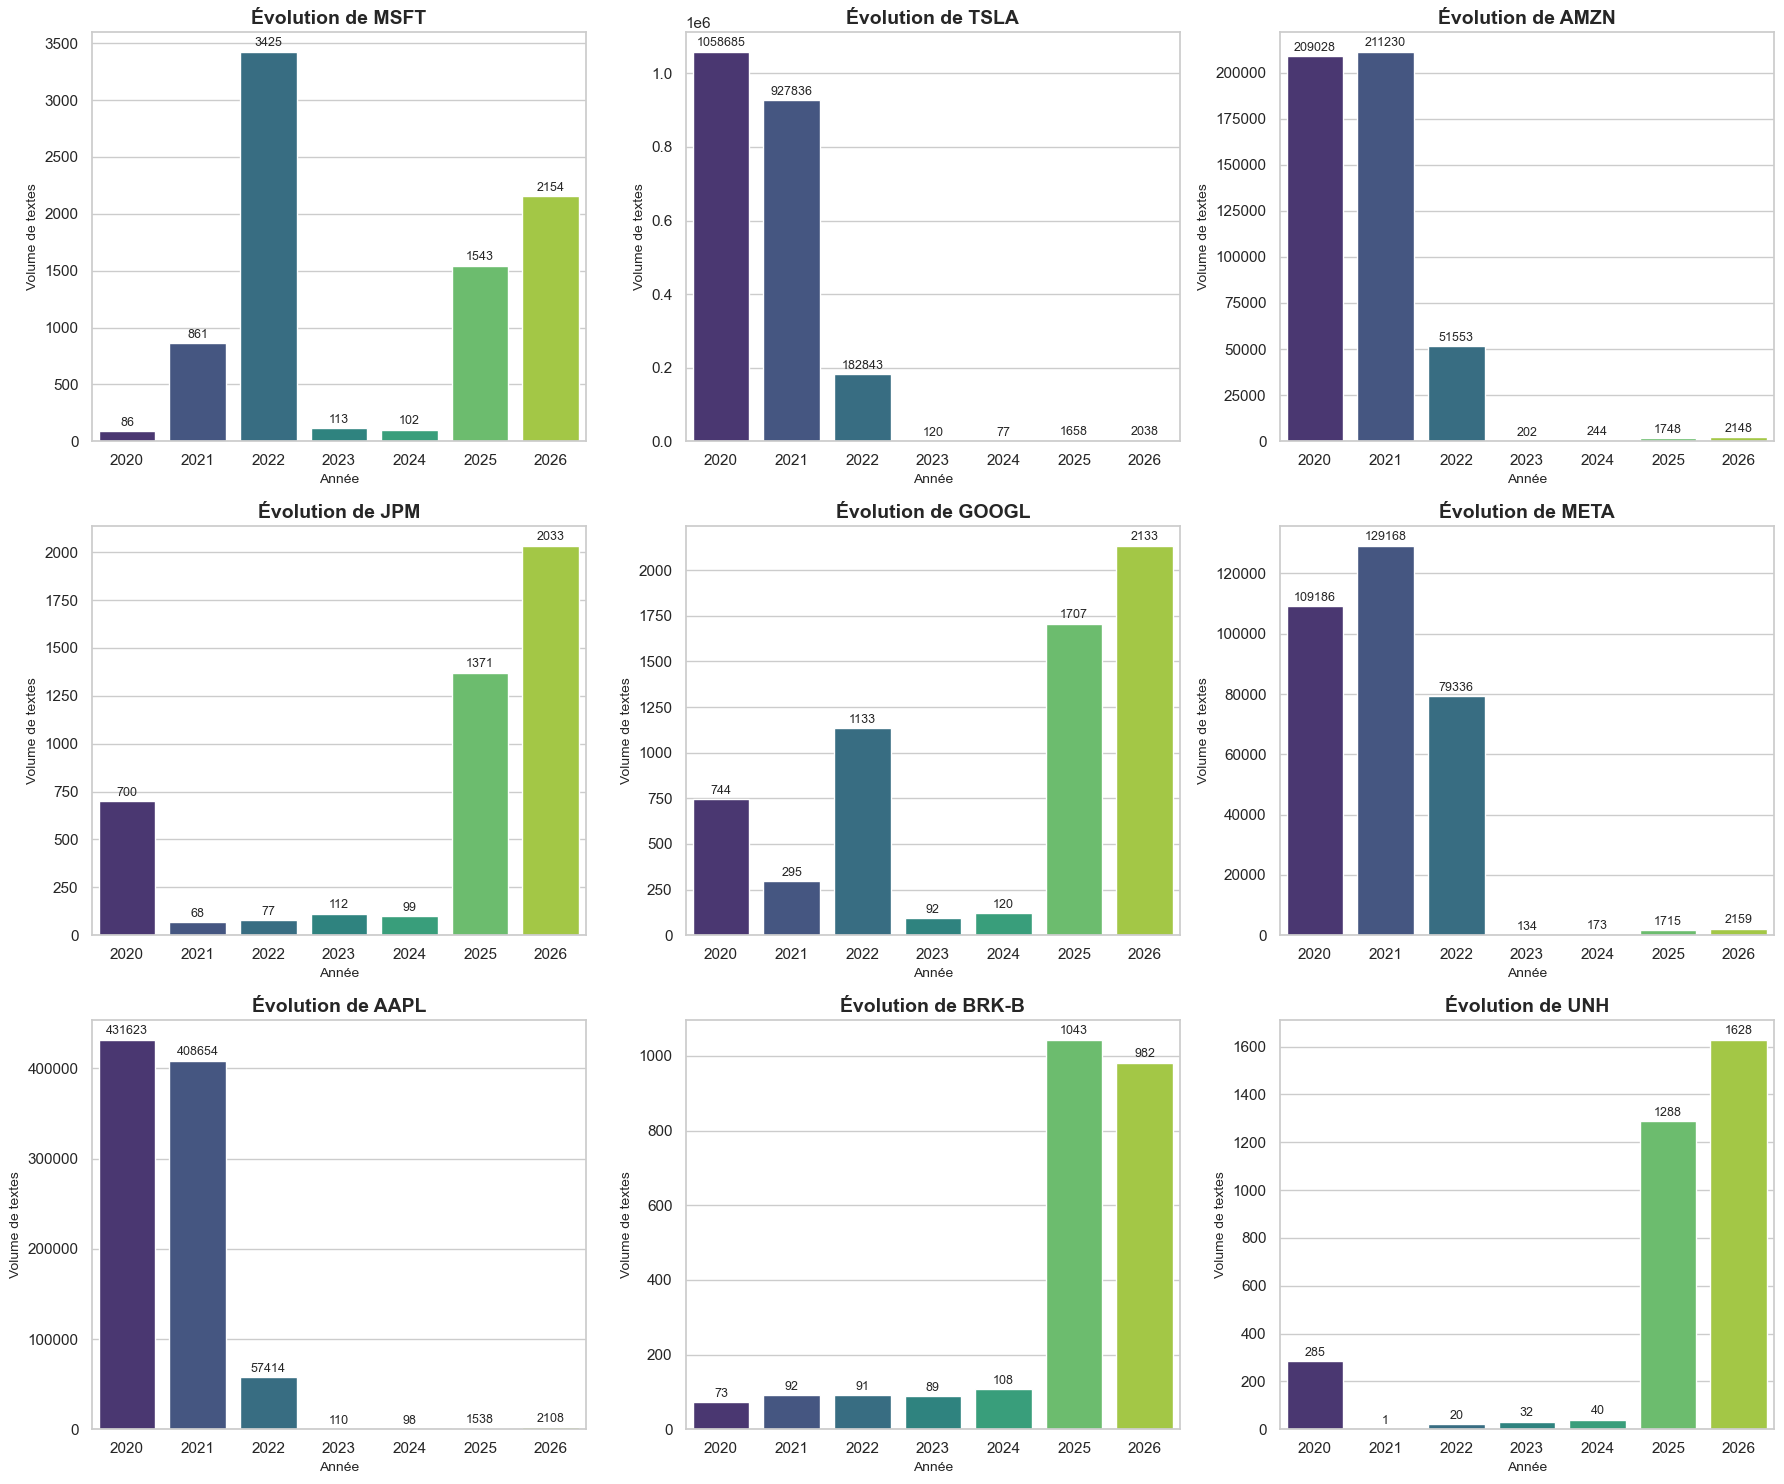

In [20]:


# 1. On s'assure d'avoir la colonne 'Année'
if 'Année' not in df.columns:
    df['Année'] = pd.to_datetime(df['Date']).dt.year

# 2. On récupère la liste de tous tes tickers
tickers = df['Ticker'].unique()

# 3. Configuration de la grille (3 colonnes, et on calcule le nombre de lignes nécessaires)
cols = 3
rows = math.ceil(len(tickers) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten() # Transforme la matrice en liste simple pour la boucle

# 4. LA BOUCLE MAGIQUE : un graphique par Ticker
for i, ticker in enumerate(tickers):
    # On isole les données de l'entreprise en cours
    df_ticker = df[df['Ticker'] == ticker]
    
    # On compte le nombre de textes par année et on trie l'axe X (2020 -> 2026)
    repartition = df_ticker['Année'].value_counts().sort_index()
    
    # On dessine le graphique dans la case i
    sns.barplot(x=repartition.index, y=repartition.values, ax=axes[i], palette="viridis")
    
    # Titres et labels
    axes[i].set_title(f"Évolution de {ticker}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Année", fontsize=10)
    axes[i].set_ylabel("Volume de textes", fontsize=10)
    
    # Ajout des chiffres au-dessus de chaque barre pour une précision maximale
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 6), 
                         textcoords='offset points',
                         fontsize=9)

# 5. Nettoyage : On supprime les cases vides à la fin de la grille s'il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Affichage optimisé
plt.tight_layout()
plt.show()

### 📊 Conclusion de l'EDA et Choix Stratégique

L'Analyse Exploratoire des Données (EDA) sur notre dataset brut initial de 3,8 millions de lignes a mis en lumière **deux anomalies critiques** qui auraient lourdement biaisé l'apprentissage de notre modèle :

*   **Un déséquilibre de classes extrême :** L'action Tesla (`TSLA`) écrasait à elle seule le reste du dataset avec plus de 2,1 millions de messages.
*   **Une fracture chronologique et stylistique :** Les données textuelles étaient séparées en deux mondes étanches. D'un côté, le Top 4 (`TSLA`, `AAPL`, `AMZN`, `META`) ultra-volumineux, centré sur le langage informel et spéculatif des réseaux sociaux entre 2020 et 2022. De l'autre, les tickers restants, limités à de courts flux d'actualités institutionnelles et très formels sur la période 2025-2026.

---

### 🛠️ Pistes de Résolution

Face à cette asymétrie, trois stratégies ont été étudiées :

*   **La Solution B (L'approche institutionnelle) :** Conserver l'ensemble des actions, mais appliquer un sous-échantillonnage drastique sur le Top 4 pour s'aligner sur les faibles volumes des années 2025-2026.
*   **La Solution C (L'approche hybride) :** Scinder le projet en créant deux modèles distincts (un modèle "réseaux sociaux" pour 2020-2022 et un modèle "actualité financière" pour 2025-2026).
*   **La Solution A (Le focus mass-data) :** Restreindre le périmètre d'étude exclusivement au Top 4 des Big Tech sur la période 2020-2022.

---

### 🎯 Décision pour la Phase de Test

> **Nous décidons d'implémenter la Solution A en première ligne pour nos tests.**

Afin de valider notre pipeline technique et d'éprouver le modèle FinBERT dans les meilleures conditions possibles, ce choix stratégique est le plus pertinent. Il nous permet de :

*   Garantir une **cohérence temporelle** stricte.
*   Maximiser le **volume de données homogènes**.
*   Empêcher l'IA d'apprendre des **corrélations factices** liées à des cycles économiques discordants.

*Une fois notre approche validée sur ce socle solide, nous pourrons itérer vers les autres solutions.*

## Solution A

In [25]:
top_4_tickers = ['TSLA', 'AAPL', 'AMZN', 'META']
annees_cibles = [2020, 2021, 2022]

print(f" Dimensions avant filtrage : {df.shape}")


df['Année_Temp'] = pd.to_datetime(df['Date'], errors='coerce').dt.year


df_2020_2022 = df[
    (df['Ticker'].isin(top_4_tickers)) & 
    (df['Année_Temp'].isin(annees_cibles))
].copy()


df_2020_2022 = df_2020_2022.drop(columns=['Année_Temp'])


df_2020_2022 = df_2020_2022.reset_index(drop=True)


print("SOLUTION A APPLIQUÉE AVEC SUCCÈS !")
print(f" Dimensions du nouveau dataset d'entraînement : {df_2020_2022.shape}")
print(f" Tickers conservés : {df_2020_2022['Ticker'].unique()}")
print(f" Plage de dates : du {df_2020_2022['Date'].min()} au {df_2020_2022['Date'].max()}")


 Dimensions avant filtrage : (3897566, 6)
SOLUTION A APPLIQUÉE AVEC SUCCÈS !
 Dimensions du nouveau dataset d'entraînement : (3856556, 5)
 Tickers conservés : ['META' 'AAPL' 'AMZN' 'TSLA']
 Plage de dates : du 2020-01-01 au 2022-12-31


In [26]:
df_2020_2022

,Date,Source,Ticker,Titre,Année
0,2022-12-31,MarketWatch,META,These 20 stocks were the biggest losers of 202...,2022
1,2022-12-31,MarketWatch,AAPL,Buy shares of only the strongest companies to ...,2022
2,2022-12-31,MarketWatch,AMZN,Disney breaks below 2020 low to record its che...,2022
3,2022-12-31,MarketWatch,AMZN,These 20 stocks were the biggest losers of 202...,2022
4,2022-12-30,thestreet.com,AMZN,Did Amazon Stock Bottom in 2022 or Are More Lo...,2022
...,...,...,...,...,...
3856551,2020-01-01,StockTwits,TSLA,Tesla faces lawsuit claiming racism https://se...,2020
3856552,2020-01-01,StockTwits,TSLA,@NyParker @dennismccain My opinion on $NIO (I ...,2020
3856553,2020-01-01,StockTwits,TSLA,$TSLA haha just a collection of greats...&quot...,2020
3856554,2020-01-01,StockTwits,TSLA,Tesla faces lawsuit claiming racism https://se...,2020


In [27]:
df_2020_2022 = df_2020_2022.drop(columns=['Année'])

chemin_final = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\MASTER_DATASET_2020_2022_TOP4.csv"


df_2020_2022.to_csv(chemin_final, index=False, encoding='utf-8')

print(f" Colonne supprimée avec succès !")
print(f" Fichier final sauvegardé dans : {chemin_final}")
print(f" Dimensions finales du fichier : {df_2020_2022.shape}")

 Colonne supprimée avec succès !
 Fichier final sauvegardé dans : C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\MASTER_DATASET_2020_2022_TOP4.csv
 Dimensions finales du fichier : (3856556, 4)


In [28]:
df_2020_2022

,Date,Source,Ticker,Titre
0,2022-12-31,MarketWatch,META,These 20 stocks were the biggest losers of 202...
1,2022-12-31,MarketWatch,AAPL,Buy shares of only the strongest companies to ...
2,2022-12-31,MarketWatch,AMZN,Disney breaks below 2020 low to record its che...
3,2022-12-31,MarketWatch,AMZN,These 20 stocks were the biggest losers of 202...
4,2022-12-30,thestreet.com,AMZN,Did Amazon Stock Bottom in 2022 or Are More Lo...
...,...,...,...,...
3856551,2020-01-01,StockTwits,TSLA,Tesla faces lawsuit claiming racism https://se...
3856552,2020-01-01,StockTwits,TSLA,@NyParker @dennismccain My opinion on $NIO (I ...
3856553,2020-01-01,StockTwits,TSLA,$TSLA haha just a collection of greats...&quot...
3856554,2020-01-01,StockTwits,TSLA,Tesla faces lawsuit claiming racism https://se...


In [29]:
import re
import html

def nettoyer_texte_finbert(texte):
    # Sécurité pour les valeurs nulles
    if not isinstance(texte, str):
        return ""
    
    # 1. Décoder le HTML (ex: transforme "&amp;" en "&")
    texte = html.unescape(texte)
    
    # 2. Supprimer les URLs (http, https, www)
    texte = re.sub(r'http\S+|www\S+|https\S+', '', texte, flags=re.MULTILINE)
    
    # 3. Supprimer les mentions utilisateurs (@username)
    texte = re.sub(r'\@\w+', '', texte)
    
    # 4. Optionnel : On peut garder les cashtags ($TSLA) car FinBERT les connait souvent, 
    # mais on retire les espaces en trop.
    texte = re.sub(r'\s+', ' ', texte).strip()
    
    return texte

# Application sur ton dataset
print("🧹 Lancement du nettoyage...")
df_2020_2022['Texte_Nettoye'] = df_2020_2022['Titre'].apply(nettoyer_texte_finbert)

print("✅ Nettoyage terminé !")
display(df_2020_2022[['Titre', 'Texte_Nettoye']].head())

🧹 Lancement du nettoyage...
✅ Nettoyage terminé !


,Titre,Texte_Nettoye
0,These 20 stocks were the biggest losers of 202...,These 20 stocks were the biggest losers of 202...
1,Buy shares of only the strongest companies to ...,Buy shares of only the strongest companies to ...
2,Disney breaks below 2020 low to record its che...,Disney breaks below 2020 low to record its che...
3,These 20 stocks were the biggest losers of 202...,These 20 stocks were the biggest losers of 202...
4,Did Amazon Stock Bottom in 2022 or Are More Lo...,Did Amazon Stock Bottom in 2022 or Are More Lo...


In [30]:
df_2020_2022

,Date,Source,Ticker,Titre,Texte_Nettoye
0,2022-12-31,MarketWatch,META,These 20 stocks were the biggest losers of 202...,These 20 stocks were the biggest losers of 202...
1,2022-12-31,MarketWatch,AAPL,Buy shares of only the strongest companies to ...,Buy shares of only the strongest companies to ...
2,2022-12-31,MarketWatch,AMZN,Disney breaks below 2020 low to record its che...,Disney breaks below 2020 low to record its che...
3,2022-12-31,MarketWatch,AMZN,These 20 stocks were the biggest losers of 202...,These 20 stocks were the biggest losers of 202...
4,2022-12-30,thestreet.com,AMZN,Did Amazon Stock Bottom in 2022 or Are More Lo...,Did Amazon Stock Bottom in 2022 or Are More Lo...
...,...,...,...,...,...
3856551,2020-01-01,StockTwits,TSLA,Tesla faces lawsuit claiming racism https://se...,Tesla faces lawsuit claiming racism $TSLA 🤦‍♂️...
3856552,2020-01-01,StockTwits,TSLA,@NyParker @dennismccain My opinion on $NIO (I ...,My opinion on $NIO (I traded it multiple times...
3856553,2020-01-01,StockTwits,TSLA,$TSLA haha just a collection of greats...&quot...,"$TSLA haha just a collection of greats...""Mars..."
3856554,2020-01-01,StockTwits,TSLA,Tesla faces lawsuit claiming racism https://se...,Tesla faces lawsuit claiming racism $TSLA


In [31]:
chemin_final = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\MASTER_DATASET_2020_2022_TOP4_processed.csv"

df_2020_2022.to_csv(chemin_final, index=False, encoding='utf-8')